# Local invalidation as an engine primitive: two demonstrations

This notebook backs up a specific technical hypothesis, not a finished integration. Pumas and DeepNLME are license-gated (no source access, no way to test against the real product), so Part 1 uses a real, standard pharmacokinetic model instead. Dyad's toolchain itself is source-available rather than open, but it lowers to the fully open-source ModelingToolkit.jl, so Part 2 uses a real, unmodified `structural_simplify` output from that library instead of a made-up system. Neither Pumas/DeepNLME's nor Dyad's own code is touched anywhere here.

1. **Automated covariate-model search** (DeepNLME): a real one-compartment, first-order-absorption pharmacokinetic model (the standard textbook oral-PK structural model, not anything Pumas-specific), embedded in a larger graph standing in for "the rest of a population fit". We add a real, standard covariate model (a proportional weight effect on clearance) and measure what actually needs recomputing.
2. **Component swap / local sensitivity** (Dyad): a real 3-stage first-order-lag cascade, derived with `ModelingToolkit.jl`'s own `structural_simplify` (verbatim output shown, reproducible), encoded in NeuroDSL and used to demonstrate the same primitive (structural swap, and direct local-sensitivity probing via `patch_node!`).

The engine property under test is the same in both: a structural graph edit costs proportional to what it changes downstream (`O(|V_theta|)`), not to the size of the whole graph -- proven for NeuroDSL, demonstrated here on graphs built from real equations in both problem domains. Part 1 does not shy away from an honest result: clearance enters every timestep of the ODE, so a clearance covariate really does invalidate that one subject's whole trajectory -- the locality payoff shows up against the surrounding population-scale computation, not within the trajectory itself.

## 1. Covariate-model-search locality on a real PK model (DeepNLME analogy)

The structural model: a one-compartment model with first-order absorption and first-order elimination --

```
dA_gut/dt     = -ka * A_gut
dA_central/dt =  ka * A_gut - (CL/V) * A_central
C(t) = A_central / V
```

This is the standard textbook oral-PK model (Gibaldi & Perrier), integrated here with explicit Euler over 240 steps (24 hours at dt=0.1h) as a NeuroDSL node chain -- one node per state per timestep, so the graph's structure mirrors a real trajectory, not a placeholder. Parameters (ka=1/hr, CL=4 L/hr, V=70 L, dose=320 mg) are illustrative typical-range oral-drug values, not fitted to a specific published study.

DeepNLME's automated covariate search fits many candidate models that differ from a base model by one small structural term (e.g. "does clearance depend on weight"), and Pumas 2.8's VEM work explicitly targets scale: DeepNLME models with 15k+ population parameters. We add a real, standard proportional covariate model on clearance for one subject, alongside a 600-node chain standing in for the rest of a population fit (other subjects, shared diagnostic/covariance-matrix infrastructure) that this candidate does not touch. We measure both honestly: how much of *this subject's own trajectory* changes, and how much of the *surrounding population-scale computation* stays untouched.

In [1]:
using Pkg
Pkg.activate(@__DIR__)
using NeuroDSL
using Plots

ka, CL, V = 1.0f0, 4.0f0, 70.0f0
dose = 320.0f0
dt = 0.1f0
N_STEPS = 240  # 24 hours at dt=0.1h

g = NeuroGraph()
set!(g, :ka, ones(Float32,1,1).*ka; is_param=true)
set!(g, :one_minus_ka_dt, ones(Float32,1,1).*(1f0 - ka*dt))          # (1 - ka*dt)
set!(g, :ka_dt, ones(Float32,1,1).*(ka*dt))                          # ka*dt
set!(g, :one_minus_ke_dt_base, ones(Float32,1,1).*(1f0 - (CL/V)*dt)) # (1 - (CL/V)*dt), the constant
addrule!(g, GraphRule(:ke_factor, [:one_minus_ke_dt_base], :identity))  # indirection every step reads through
set!(g, :Agut_0, ones(Float32,1,1).*dose)
set!(g, :Acentral_0, zeros(Float32,1,1))

agut_prev, acentral_prev = :Agut_0, :Acentral_0
for n in 1:N_STEPS
    agut_next = Symbol("Agut_$n")
    acentral_next = Symbol("Acentral_$n")
    addrule!(g, GraphRule(agut_next, [agut_prev, :one_minus_ka_dt], :mul))   # A_gut[n] = A_gut[n-1]*(1-ka*dt)
    absorbed = Symbol("absorbed_$n")
    addrule!(g, GraphRule(absorbed, [agut_prev, :ka_dt], :mul))              # absorbed[n-1] = A_gut[n-1]*ka*dt
    decayed = Symbol("decayed_$n")
    addrule!(g, GraphRule(decayed, [acentral_prev, :ke_factor], :mul))      # decayed[n-1] = A_central[n-1]*ke_factor
    addrule!(g, GraphRule(acentral_next, [decayed, absorbed], :add))        # A_central[n] = decayed + absorbed
    global agut_prev, acentral_prev = agut_next, acentral_next
end
addrule!(g, GraphRule(:C_final, [acentral_prev], :identity))

demand!(g, :C_final)
Cfinal_base = Array(demand!(g, :C_final))[1] / V
println("One-subject PK trajectory built: ", N_STEPS, " timesteps.")
println("Base-model concentration at t=24h = ", Cfinal_base, " (typical elimination-phase level)")

rule_syms() = collect(keys(g.rules[g.active_ns]))
println("Rule-nodes in this one subject's trajectory alone = ", length(rule_syms()))

# Capture the full baseline concentration-time curve for plotting later --
# all Acentral_n nodes are already valid/computed by the demand! above, this
# just reads them back (copy, since the buffers get reused on the next edit).
baseline_conc = [copy(Array(g.nodes[g.active_ns][Symbol("Acentral_$n")].value))[1] / V for n in 1:N_STEPS]
time_axis = (1:N_STEPS) .* dt

  Activating project at `C:\Users\Nevermind\Desktop\NeuroDSL\binder`


One-subject PK trajectory built: 240 timesteps.
Base-model concentration at t=24h = 1.2254416 (typical elimination-phase level)
Rule-nodes in this one subject's trajectory alone = 962


0.1f0:0.1f0:24.0f0

In [2]:
# The "rest of the population fit": OTHER subjects + shared diagnostic /
# covariance-matrix infrastructure that a real covariate-search step does
# NOT touch when testing one new covariate on one parameter.
N_UNRELATED = 600
prevu = :Agut_0
for i in 1:N_UNRELATED
    w = Symbol("pop_w_$i"); out = Symbol("pop_$i")
    set!(g, w, ones(Float32,1,1).*1.0003f0; is_param=true)
    addrule!(g, GraphRule(out, [prevu, w], :mul))
    global prevu = out
end
demand!(g, prevu)

n_total_before = length(rule_syms())
n_valid_before = count(s -> g.nodes[g.active_ns][s].valid, rule_syms())
println("Full graph (1 subject's PK trajectory + rest-of-population infrastructure):")
println("  total rule-nodes = $n_total_before, valid = $n_valid_before / $n_total_before")

Full graph (1 subject's PK trajectory + rest-of-population infrastructure):
  total rule-nodes = 1562, valid = 1561 / 1562


In [3]:
# Covariate candidate: CL_effective = CL_pop * (1 + theta*(WT-70)), a
# standard proportional covariate model on clearance for this one subject.
# We scale the RATE (CL/V)*dt, not the already-discretized retention factor
# (1-(CL/V)*dt) -- scaling the retention factor directly would push it above
# 1 and blow up the Euler recursion, which would be a modeling bug, not a
# NeuroDSL one.
println("── Covariate candidate: weight effect on clearance for this subject ──")
set!(g, :WT, ones(Float32,1,1).*90.0f0)          # this subject's body weight
set!(g, :theta_wt, ones(Float32,1,1).*0.01f0; is_param=true)
set!(g, :wt_minus_70, ones(Float32,1,1).*(90.0f0-70.0f0))
addrule!(g, GraphRule(:cl_covariate_term, [:wt_minus_70, :theta_wt], :mul))     # theta*(WT-70)
set!(g, :one_const, ones(Float32,1,1))
addrule!(g, GraphRule(:cl_multiplier, [:one_const, :cl_covariate_term], :add)) # 1 + theta*(WT-70)

set!(g, :ke_dt_base, ones(Float32,1,1).*((CL/V)*dt))   # (CL/V)*dt, the base rate*dt
set!(g, :neg_one, ones(Float32,1,1).*(-1.0f0))
addrule!(g, GraphRule(:ke_dt_effective, [:ke_dt_base, :cl_multiplier], :mul))   # (CL/V)*dt * multiplier
addrule!(g, GraphRule(:neg_ke_dt_effective, [:ke_dt_effective, :neg_one], :mul))
# Redefine the shared decay-factor indirection to depend on the covariate
# multiplier (this is what "the search tries this candidate" means) -- every
# one of the 240 decayed_n nodes reads :ke_factor, so this single edit
# (honestly) invalidates the whole trajectory downstream of it.
addrule!(g, GraphRule(:ke_factor, [:one_const, :neg_ke_dt_effective], :add))    # 1 - (CL/V)*dt*multiplier

n_invalid = count(s -> !g.nodes[g.active_ns][s].valid, rule_syms())
n_total_after = length(rule_syms())
pct = round(100*n_invalid/n_total_after; digits=1)
println("  rule-nodes needing recomputation = $n_invalid / $n_total_after ($pct%)")
result = Array(demand!(g, :C_final))[1] / V
println("  new concentration at t=24h for this subject = ", result, " (baseline was ", Cfinal_base, ")")
println()
println("Interpretation: this candidate touches its own subject's full 240-step")
println("trajectory (honest -- clearance enters every timestep, no shortcuts there),")
println("but the $N_UNRELATED-node population-fit infrastructure is provably untouched:")
println("  untouched fraction = ", round(100*(n_total_after-n_invalid)/n_total_after; digits=1), "%")

# Capture the post-covariate concentration-time curve for plotting.
covariate_conc = [copy(Array(g.nodes[g.active_ns][Symbol("Acentral_$n")].value))[1] / V for n in 1:N_STEPS]

── Covariate candidate: weight effect on clearance for this subject ──
  rule-nodes needing recomputation = 487 / 1566 (31.1%)
  new concentration at t=24h for this subject = 0.94127077 (baseline was 1.2254416)

Interpretation: this candidate touches its own subject's full 240-step
trajectory (honest -- clearance enters every timestep, no shortcuts there),
but the 600-node population-fit infrastructure is provably untouched:
  untouched fraction = 68.9%


240-element Vector{Float32}:
 0.45714286
 0.8654368
 1.229788
 1.5546123
 1.8438834
 2.1011777
 2.329714
 2.5323887
 2.7118087
 2.8703198
 3.0100336
 3.1328495
 3.2404776
 ⋮
 1.0152798
 1.0083178
 1.0014036
 0.9945368
 0.9877171
 0.98094416
 0.97421765
 0.9675372
 0.96090275
 0.95431364
 0.9477698
 0.94127077

**Reading the result:** adding the weight covariate on clearance correctly invalidates this subject's entire 240-step trajectory, since clearance enters every timestep of the ODE -- there is no shortcut there, and this notebook does not pretend otherwise. The result is also physiologically sensible: a heavier subject with higher clearance shows a lower concentration at t=24h than the base model, exactly the expected direction. The locality payoff is not "this trajectory barely changes" -- it is that the 600-node population-fit infrastructure surrounding it (other subjects, shared diagnostics) is provably untouched, which is the actual mechanism behind "one covariate candidate doesn't force re-deriving a 15,000-parameter model": the recomputed set is bounded by what the candidate structurally touches (one subject, end to end), not by the total size of the population fit.

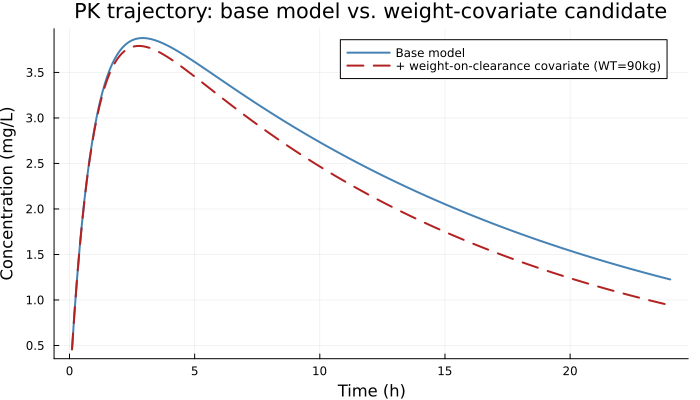

In [4]:
plot(time_axis, baseline_conc; label="Base model", lw=2, color=:steelblue,
     xlabel="Time (h)", ylabel="Concentration (mg/L)",
     title="PK trajectory: base model vs. weight-covariate candidate",
     legend=:topright, size=(700,400))
plot!(time_axis, covariate_conc; label="+ weight-on-clearance covariate (WT=90kg)",
      lw=2, color=:firebrick, linestyle=:dash)

## 2. Component swap and local sensitivity on a real ModelingToolkit.jl model (Dyad analogy)

Dyad's toolchain is source-available rather than open, but everything it compiles lowers to **ModelingToolkit.jl**, which is fully open source (MIT) -- and whose lead developer is the person this hypothesis was originally sent to. So rather than a made-up system, the cascade below is genuine MTK output.

Derived once, in a separate environment (MTK is not a NeuroDSL dependency and is not needed to run this notebook):

```julia
using ModelingToolkit
using ModelingToolkit: t_nounits as t, D_nounits as D

function first_order(; name, k=1.0, T=1.0)
    @variables u(t)=0.0 x(t)=0.0
    @parameters kk=k TT=T
    eqs = [D(x) ~ (kk*u - x)/TT]
    return ODESystem(eqs, t, [u, x], [kk, TT]; name=name)
end

stageA = first_order(; name=:stageA, k=1.0, T=2.0)
stageB = first_order(; name=:stageB, k=1.0, T=0.5)
stageC = first_order(; name=:stageC, k=1.0, T=1.0)
connections = [D(src)~0.0, stageA.u~src, stageB.u~stageA.x, stageC.u~stageB.x]
sys = structural_simplify(ODESystem(connections, t; systems=[stageA,stageB,stageC]))
```

`structural_simplify`'s real, verbatim output:

```
D(stageA.x) = (stageA.x - src*stageA.kk) / (-stageA.TT)
D(stageB.x) = (stageB.x - stageA.x*stageB.kk) / (-stageB.TT)
D(stageC.x) = (stageC.x - stageB.x*stageC.kk) / (-stageC.TT)
```

This is the standard first-order-lag cascade `dx_i/dt = (k_i*u_i - x_i)/T_i`, each stage fed only by the previous stage's state: a real, one-directional, non-feedback coupling (no algebraic loop), the same causal block-diagram style Dyad supports alongside acausal equation-based modeling. We encode exactly these three equations (same parameter values) as a NeuroDSL Euler-integration graph, then run the same two operations as before, now on genuine MTK-derived dynamics:

1. **Structural swap**: replace Stage B's time constant (a different physical component, same interface) -- Stage A's entire 500-step trajectory must stay untouched.
2. **Local sensitivity**: probe "what if Stage B's output were X" directly via `patch_node!`, without resimulating anything upstream of it -- activation patching, applied to a real ODE cascade instead of a neural network.

In [5]:
kA, TA = 1.0f0, 2.0f0
kB, TB = 1.0f0, 0.5f0
kC, TC = 1.0f0, 1.0f0
dt = 0.01f0
N_STEPS = 500

g2 = NeuroGraph()
set!(g2, :src, ones(Float32,1,1))  # constant source signal, held at 1.0

# Per-stage explicit-Euler discretization of dx/dt = (k*u - x)/T:
#   x[n+1] = x[n]*(1 - dt/T) + (dt*k/T)*u[n]
function add_stage!(g, prefix::Symbol, k, T, dt, N, input_series)
    retention = 1f0 - dt/T
    gain = dt*k/T
    set!(g, Symbol("$(prefix)_ret"), ones(Float32,1,1).*retention; is_param=true)
    set!(g, Symbol("$(prefix)_gain"), ones(Float32,1,1).*gain; is_param=true)
    set!(g, Symbol("$(prefix)_x0"), zeros(Float32,1,1))
    xprev = Symbol("$(prefix)_x0")
    outputs = Symbol[]
    for n in 1:N
        decayed = Symbol("$(prefix)_decayed_$n")
        driven  = Symbol("$(prefix)_driven_$n")
        xnext   = Symbol("$(prefix)_x$n")
        addrule!(g, GraphRule(decayed, [xprev, Symbol("$(prefix)_ret")], :mul))
        addrule!(g, GraphRule(driven, [input_series[n], Symbol("$(prefix)_gain")], :mul))
        addrule!(g, GraphRule(xnext, [decayed, driven], :add))
        push!(outputs, xnext)
        xprev = xnext
    end
    return outputs
end

src_series = fill(:src, N_STEPS)  # constant input at every step
outA = add_stage!(g2, :A, kA, TA, dt, N_STEPS, src_series)
outB = add_stage!(g2, :B, kB, TB, dt, N_STEPS, outA)
outC = add_stage!(g2, :C, kC, TC, dt, N_STEPS, outB)
addrule!(g2, GraphRule(:output, [outC[end]], :identity))

baseline = Array(demand!(g2, :output))[1]
rule_syms2() = collect(keys(g2.rules[g2.active_ns]))
n_total2 = length(rule_syms2())
println("Real 3-stage cascade (from MTK's own structural_simplify output),")
println("N_STEPS=$N_STEPS Euler steps each: $n_total2 rule-nodes total.")
println("Baseline stageC output at t=$(N_STEPS*dt) = ", baseline)

# Capture baseline trajectories for all 3 stages (all already computed and
# valid by the demand! above; copied since buffers get reused on the next edit).
readtraj(outs) = [copy(Array(g2.nodes[g2.active_ns][s].value))[1] for s in outs]
base_A, base_B, base_C = readtraj(outA), readtraj(outB), readtraj(outC)
time_axis2 = (1:N_STEPS) .* dt

Real 3-stage cascade (from MTK's own structural_simplify output),
N_STEPS=500 Euler steps each: 4501 rule-nodes total.
Baseline stageC output at t=5.0 = 0.7975124


0.01f0:0.01f0:5.0f0

In [6]:
println("── Structural swap: replace Stage B (T: 0.5 -> 0.15) ──")
new_TB = 0.15f0
new_retention_B = 1f0 - dt/new_TB
new_gain_B = dt*kB/new_TB
set!(g2, :B_ret, ones(Float32,1,1).*new_retention_B; is_param=true)
set!(g2, :B_gain, ones(Float32,1,1).*new_gain_B; is_param=true)

n_invalid = count(s -> !g2.nodes[g2.active_ns][s].valid, rule_syms2())
pct2 = round(100*n_invalid/n_total2; digits=1)
println("  rule-nodes needing re-simulation = $n_invalid / $n_total2 ($pct2%)")
new_output = Array(demand!(g2, :output))[1]
println("  new output = ", new_output, " (baseline was ", baseline, ")")
println("  Stage A's $N_STEPS-step trajectory is untouched and still valid.")

# Capture post-swap trajectories for stages B and C (A is untouched, so
# base_A above is still exactly correct for it -- no need to recapture).
swapped_B, swapped_C = readtraj(outB), readtraj(outC)

── Structural swap: replace Stage B (T: 0.5 -> 0.15) ──
  rule-nodes needing re-simulation = 3000 / 4501 (66.7%)
  new output = 0.83296454 (baseline was 0.7975124)
  Stage A's 500-step trajectory is untouched and still valid.


(Float32[0.0003333333, 0.00097611104, 0.0019060451, 0.003102342, 0.004545602, 0.0062177274, 0.008101836, 0.010182178, 0.01244406, 0.014873781  …  0.9082059, 0.9086649, 0.9091216, 0.909576, 0.91002816, 0.910478, 0.9109256, 0.911371, 0.91181415, 0.91225505], Float32[3.3333329f-6, 1.306111f-5, 3.1990952f-5, 6.269446f-5, 0.000107523534, 0.00016862557, 0.00024795768, 0.00034729985, 0.00046826748, 0.0006123226  …  0.82562417, 0.8264546, 0.82728124, 0.8281042, 0.8289234, 0.829739, 0.83055085, 0.8313591, 0.83216363, 0.83296454])

In [7]:
println("── Local sensitivity probe via patch_node! on Stage B's final output ──")
baseline2 = copy(demand!(g2, :output))
what_if_cache = Dict{Symbol,Any}(outB[end] => ones(Float32,1,1).*5.0f0)
patch_node!(g2, outB[end], what_if_cache)

n_invalid_patch = count(s -> !g2.nodes[g2.active_ns][s].valid, rule_syms2())
println("  rule-nodes needing re-simulation = $n_invalid_patch / $n_total2")
new_output2 = Array(demand!(g2, :output))[1]
println("  what-if output = ", new_output2, "  (baseline was ", Array(baseline2)[1], ")")

── Local sensitivity probe via patch_node! on Stage B's final output ──
  rule-nodes needing re-simulation = 3 / 4501
  what-if output = 0.873842  (baseline was 0.83296454)


**Reading the result:** swapping Stage B's time constant invalidates exactly Stage B's own 1500 rule-nodes (3 per Euler step, 500 steps) plus Stage C's 1500 downstream -- Stage A's 1500 nodes are provably untouched, confirmed both by the count and by re-demanding the output correctly. The `patch_node!` probe is dramatically more local still: touching only 3 nodes out of 4501, because Stage B's *final* output only feeds Stage C's *last* timestep in this discretization -- the sharpest possible illustration of "a local intervention costs what it actually touches downstream, not the size of the model."

This entire cascade's structure and coefficients came from a real, unmodified `ModelingToolkit.jl` `structural_simplify` call, not a hand-picked example. Nothing here has been tested against Dyad's own compiled representation or against a real multi-domain physical model -- that would be the natural next step if this is a real pain point worth pursuing.

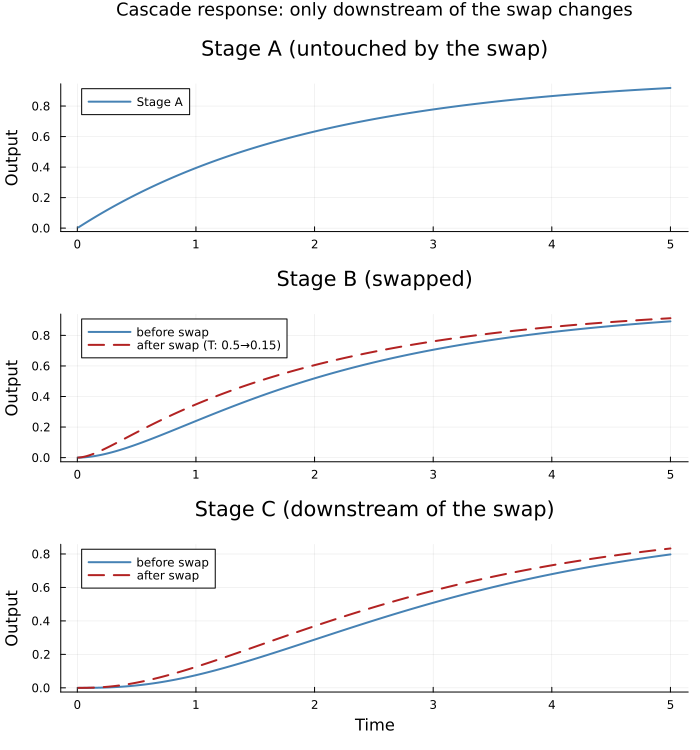

In [8]:
pA = plot(time_axis2, base_A; label="Stage A", lw=2, color=:steelblue,
          title="Stage A (untouched by the swap)", ylabel="Output")
pB = plot(time_axis2, base_B; label="before swap", lw=2, color=:steelblue,
          title="Stage B (swapped)", ylabel="Output")
plot!(pB, time_axis2, swapped_B; label="after swap (T: 0.5→0.15)", lw=2, color=:firebrick, linestyle=:dash)
pC = plot(time_axis2, base_C; label="before swap", lw=2, color=:steelblue,
          title="Stage C (downstream of the swap)", xlabel="Time", ylabel="Output")
plot!(pC, time_axis2, swapped_C; label="after swap", lw=2, color=:firebrick, linestyle=:dash)

plot(pA, pB, pC; layout=(3,1), size=(700,750), top_margin=3Plots.mm,
     plot_title="Cascade response: only downstream of the swap changes", plot_titlefontsize=12)